**Theory: Scaling and Thresholding in Image Transformation**


**Scaling**

Scaling is a geometric transformation technique used in digital image processing to change the size of an image. It enlarges or reduces the dimensions of an image while maintaining its overall appearance. Scaling is performed by multiplying the coordinates of image pixels by scaling factors along the horizontal and vertical directions.

If the scaling factor is greater than 1, the image size increases (zoom in). If the scaling factor is between 0 and 1, the image size decreases (zoom out). Scaling is widely used in applications such as image resizing, computer graphics, medical imaging, satellite imaging, and multimedia systems.



**Thresholding**

Thresholding is an image processing technique used for image segmentation. It converts a grayscale image into a binary image by separating objects from the background based on pixel intensity values.

In thresholding, a threshold value is selected. Pixels with intensity values greater than or equal to the threshold are assigned one value (usually white), while pixels with intensity values lower than the threshold are assigned another value (usually black). This process simplifies image analysis and object detection.

Thresholding is commonly used in:

-Object detection

-Character recognition (OCR)

-Medical image analysis

1.Write a program to detect edge of an image.


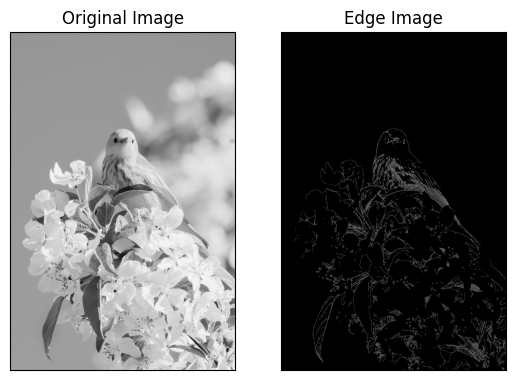

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/bird.jpg', 0)
edges = cv2.Canny(img, 100, 200)

plt.subplot(121), plt.imshow(img, cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])

plt.show()

2.Write a program to scale an image.

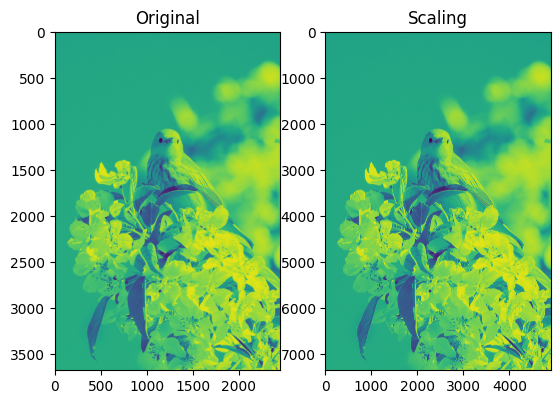

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/bird.jpg',0)

#res = cv2.resize(img,None,fx=2, fy=2, interpolation = cv2.INTER_CUBIC)

height, width = img.shape[:2]
res = cv2.resize(img,(2*width, 2*height), interpolation = cv2.INTER_CUBIC)
plt.subplot(121),plt.imshow(img),plt.title('Original')
#plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(res),plt.title('Scaling')
#plt.xticks([]), plt.yticks([])
plt.show()

3. Write a program showing a thresholding process on an image

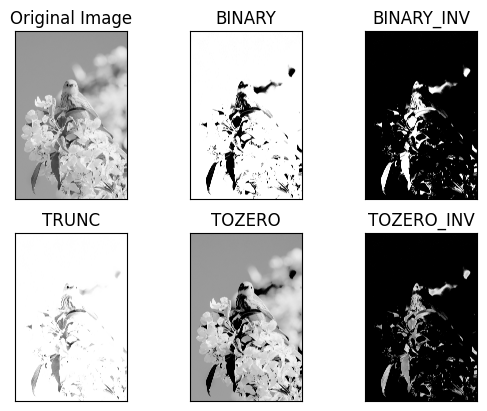

In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('/content/bird.jpg',0)

ret,thresh1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO_INV)

titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

for i in range(6):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])

plt.show()

**Gamma Transformation**

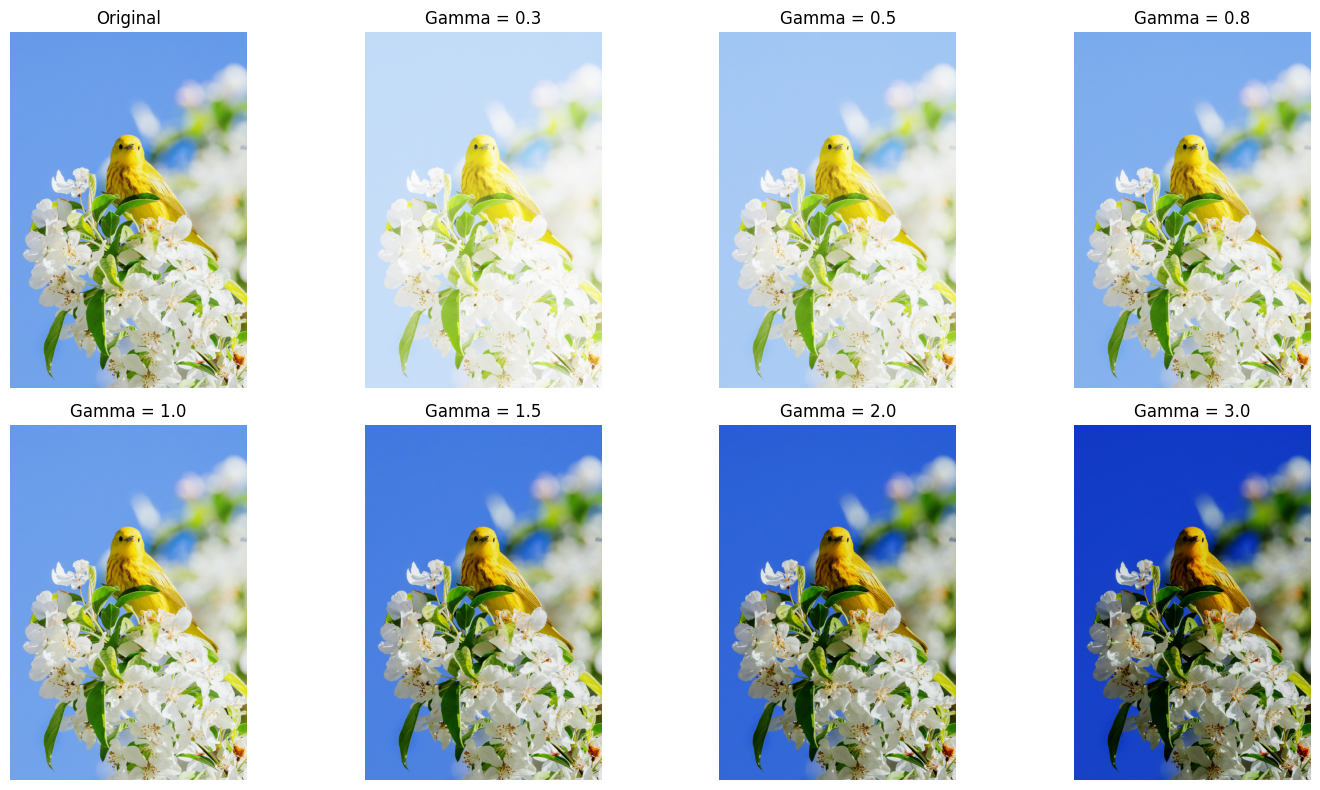

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("/content/bird.jpg")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Different gamma values
gamma_values = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0]

# Create figure
plt.figure(figsize=(15, 8))

# Show original image
plt.subplot(2, 4, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

# Apply gamma correction for each value
for i, gamma in enumerate(gamma_values):

    gamma_corrected = np.array(
        255 * (image / 255) ** gamma,
        dtype='uint8'
    )

    plt.subplot(2, 4, i + 2)
    plt.imshow(gamma_corrected)
    plt.title(f"Gamma = {gamma}")
    plt.axis("off")

# Adjust layout
plt.tight_layout()

# Show all images
plt.show()

**Log Transformation**

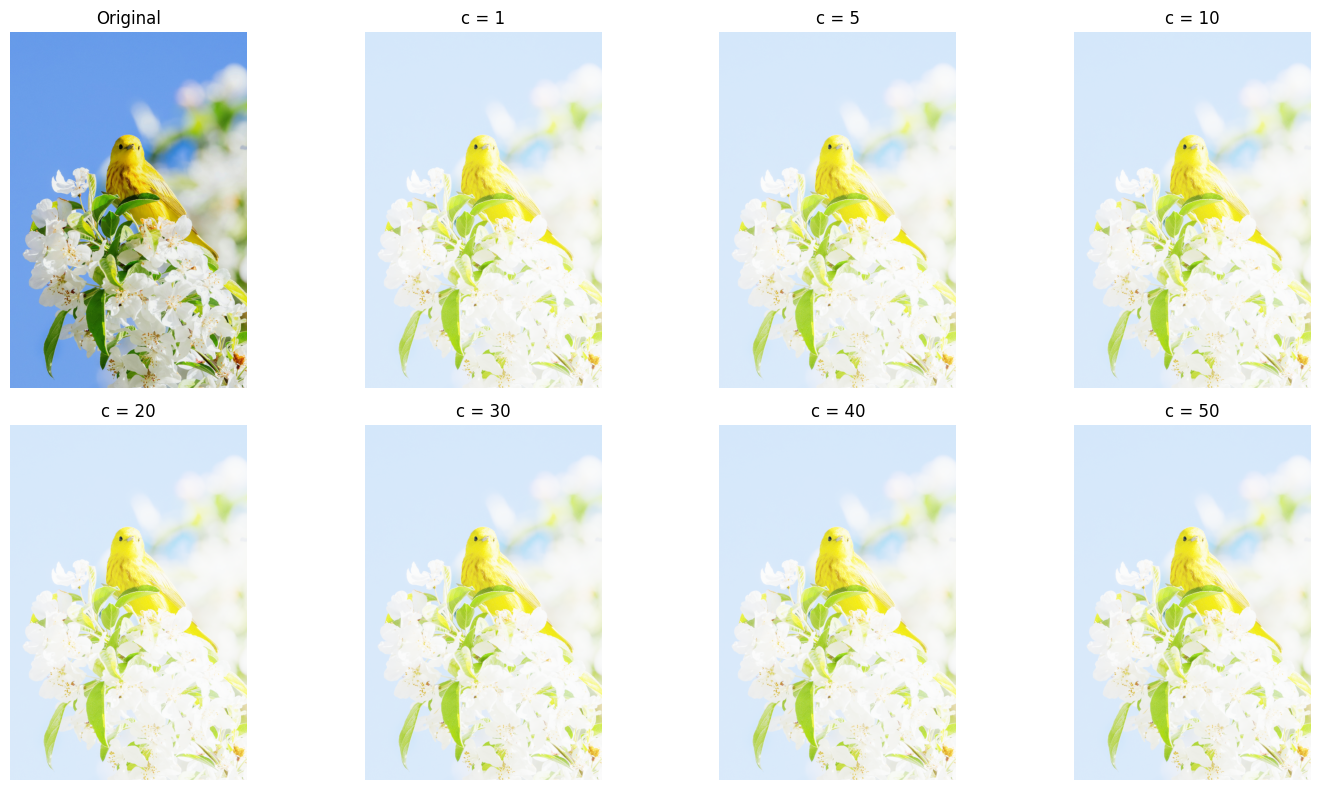

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("/content/bird.jpg")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Different constant values
c_values = [1, 5, 10, 20, 30, 40, 50]

# Create figure
plt.figure(figsize=(15, 8))

# Show original image
plt.subplot(2, 4, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

# Apply log transformation
for i, c in enumerate(c_values):

    # Convert image to float
    img_float = image.astype(np.float32)

    # Log transform
    log_transformed = c * np.log(1 + img_float)

    # Normalize to 0-255
    log_transformed = np.array(
        255 * log_transformed / np.max(log_transformed),
        dtype='uint8'
    )

    # Display
    plt.subplot(2, 4, i + 2)
    plt.imshow(log_transformed)
    plt.title(f"c = {c}")
    plt.axis("off")

# Adjust layout
plt.tight_layout()

# Show all images
plt.show()

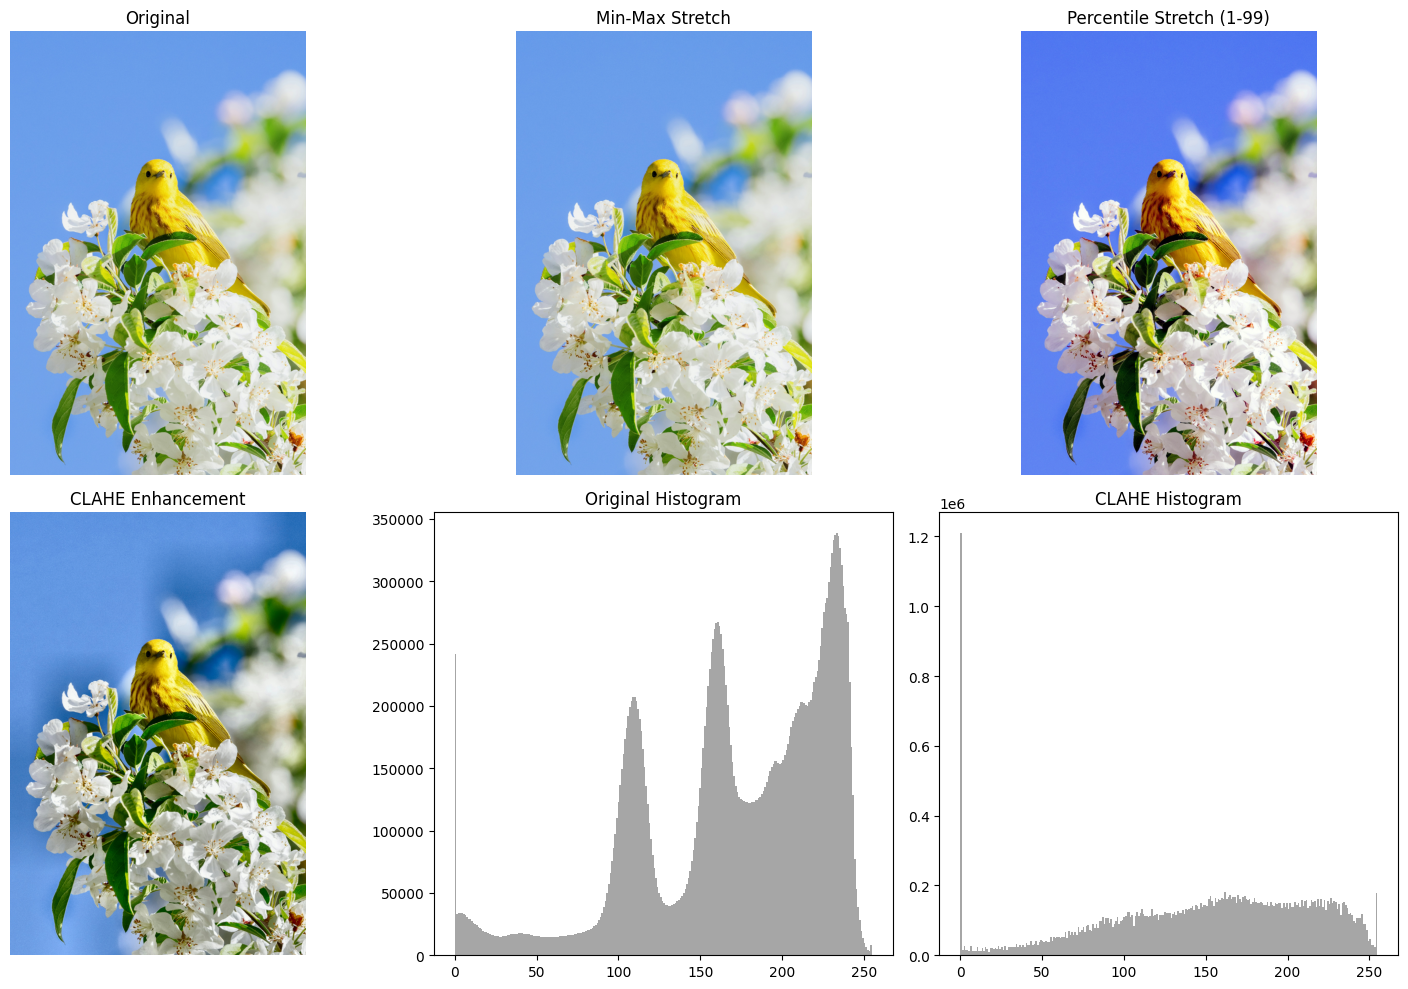

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ================== Load Image ==================
image_path = "/content/bird.jpg"
original = cv2.imread(image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# ================== Different Contrast Enhancement Methods ==================

def min_max_stretch(img):
    """Simple min-max contrast stretching"""
    stretched = np.zeros_like(img, dtype=np.float32)
    for i in range(3):
        min_val = np.min(img[:,:,i])
        max_val = np.max(img[:,:,i])
        if max_val - min_val > 0:
            stretched[:,:,i] = (img[:,:,i] - min_val) * (255.0 / (max_val - min_val))
    return np.clip(stretched, 0, 255).astype(np.uint8)

def percentile_stretch(img, low=2, high=98):
    """Better: Ignore outliers using percentiles"""
    stretched = np.zeros_like(img, dtype=np.float32)
    for i in range(3):
        p_low = np.percentile(img[:,:,i], low)
        p_high = np.percentile(img[:,:,i], high)
        if p_high - p_low > 1:
            stretched[:,:,i] = (img[:,:,i] - p_low) * (255.0 / (p_high - p_low))
        else:
            stretched[:,:,i] = img[:,:,i]
    return np.clip(stretched, 0, 255).astype(np.uint8)

def clahe_enhance(img):
    """Best for most screenshots - Local contrast enhancement"""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    enhanced_lab = cv2.merge([l, a, b])
    enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
    return enhanced

# Apply all methods
img_float = original.astype(np.float32)

result1 = min_max_stretch(img_float)
result2 = percentile_stretch(img_float, low=1, high=99)
result3 = clahe_enhance(original)

# ================== Display ==================
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(result1)
plt.title("Min-Max Stretch")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(result2)
plt.title("Percentile Stretch (1-99)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(result3)
plt.title("CLAHE Enhancement")
plt.axis("off")

# Show histograms for better comparison
plt.subplot(2, 3, 5)
plt.hist(original.ravel(), bins=256, color='gray', alpha=0.7)
plt.title("Original Histogram")

plt.subplot(2, 3, 6)
plt.hist(result3.ravel(), bins=256, color='gray', alpha=0.7)
plt.title("CLAHE Histogram")

plt.tight_layout()
plt.show()